## 1) Preparation des donnees et rendements

Ces cellules installent les bibliotheques necessaires puis charge les prix via `src.data_utils`.

- `download_adj_close(...)` recupere des prix ajustes de cloture.
- `compute_log_returns(...)` calcule les rendements logarithmiques propres pour l'analyse multivariee.

In [ ]:
!pip install yfinance
!pip install matplotlib
!pip install statsmodels
!pip install seaborn


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from src.data_utils import download_adj_close, compute_log_returns

In [26]:

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]
data = download_adj_close(tickers, start="2018-01-01", end="2026-12-31")
data = data.dropna(axis=1, how='all')

In [27]:
# Renommage des tickers pour une lecture plus claire
data = data.rename(columns={
    "AAPL": "Apple",
    "AMZN": "Amazon",
    "META": "Meta",
    "GOOGL": "Alphabet",
    "MSFT": "Microsoft"
})

print("Colonnes après renommage :", list(data.columns))

NameError: name 'close' is not defined

In [24]:
# 2. Calcul des rendements 
returns = compute_log_returns(data)

print(f"Nombre de jours analyses : {len(returns)}")

Nombre de jours analyses : 2083


## 2) Test de causalite de Granger

Cette cellule teste si les rendements d'un actif aident a predire ceux d'un autre actif.

Hypotheses du test :
- `H0` : les retards du predicteur n'ameliorent pas la prediction de la cible (pas de causalite de Granger) ;
- `H1` : au moins un retard du predicteur ameliore la prediction de la cible (causalite de Granger).

Interpretation rapide :
- une p-value faible conduit a rejeter `H0` au seuil choisi ;
- cela ne prouve pas une causalite economique structurelle.

In [25]:
def test_granger(df, target, predictor, max_lag=5):
    print(f"\n--- Test de Granger : {predictor} cause-t-il {target} ? ---")
    # Le test prend une matrice [cible, predicteur]
    test_result = grangercausalitytests(df[[target, predictor]], maxlag=max_lag, verbose=False)

    for lag in range(1, max_lag + 1):
        p_val = test_result[lag][0]["ssr_ftest"][1]
        print(f"Lag {lag}: p-value = {p_val:.4f}")


# Exemple entre Apple et Microsoft
test_granger(returns, "Apple", "Microsoft")


--- Test de Granger : MSFT cause-t-il AAPL ? ---
Lag 1: p-value = 0.0067
Lag 2: p-value = 0.0194
Lag 3: p-value = 0.0039
Lag 4: p-value = 0.0058
Lag 5: p-value = 0.0065


c:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 3) Matrice de correlation

Cette cellule visualise la correlation lineaire entre rendements des actifs.

- proche de `1` : mouvements souvent dans le meme sens ;
- proche de `-1` : mouvements souvent opposes ;
- proche de `0` : relation lineaire faible.

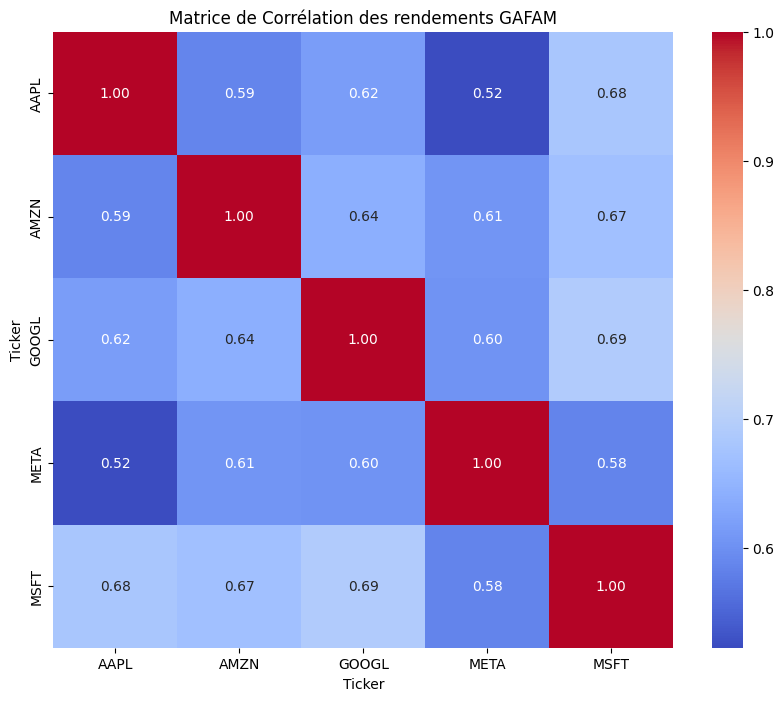

In [15]:

plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des rendements GAFAM")
plt.show()

## 4) Modele VAR et causalite jointe

Le modele VAR capte la dynamique conjointe des rendements.

Etapes de la cellule :
- selection de l'ordre de retard (`lag`) ;
- estimation du modele ;
- test de causalite multivariee dans le cadre du VAR.

In [ ]:
# Initialisation du modèle
model = VAR(returns)

# Sélection de l'ordre optimal (p) basé sur les critères d'information (AIC/BIC)
order_selection = model.select_order(maxlags=15)
print(order_selection.summary())

# Ajustement du modèle (disons p=2 selon les résultats)
results = model.fit(2)
print(results.summary())

# Test de causalité de Granger global au sein du VAR
causality = results.test_causality('Apple', ['Microsoft', 'Alphabet'], kind='f')
print(causality.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -41.45     -41.44*   9.919e-19      -41.45
1      -41.49*      -41.41  9.567e-19*     -41.46*
2       -41.48      -41.33   9.690e-19      -41.42
3       -41.48      -41.26   9.698e-19      -41.40
4       -41.47      -41.18   9.767e-19      -41.37
5       -41.46      -41.10   9.905e-19      -41.33
6       -41.45      -41.03   9.969e-19      -41.29
7       -41.45      -40.96   9.964e-19      -41.27
8       -41.44      -40.88   1.005e-18      -41.24
9       -41.44      -40.82   1.002e-18      -41.21
10      -41.43      -40.74   1.017e-18      -41.18
11      -41.42      -40.65   1.031e-18      -41.14
12      -41.41      -40.57   1.042e-18      -41.10
13      -41.40      -40.50   1.048e-18      -41.07
14      -41.39      -40.42   1.058e-18      -41.04
15      -41.37      -40.34   1.077e-18      -40.99
-------------------------------

c:\Users\denis\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
